# Weibull mixture-cure survival models

A Weibull survival model assumes that everyone will eventually experience the event. A mixture-cure model allows part of the population to never experience it. For subject $i$, survival is given by

$$S_i(t) = \pi_i + (1-\pi_i) S_{u,i}(t).$$

Here $\pi_i$ is the probability of being cured, and $S_{u,i}(t)$ is survival among subjects who will eventually experience the event. The subscript $u$ stands for *uncured*. These subjects are also called susceptible.

Bambi models the cure probability through `cure` with a logit link. The main formula models `mu`, the mean event time among susceptible subjects, with a log link, and `alpha` is their Weibull shape. The population mean event time is infinite whenever the cure probability is positive.

We use the [ECOG e1684 dataset from the R package smcure](https://search.r-project.org/CRAN/refmans/smcure/html/e1684.html), which was also analyzed by [Cai et al. (2012)](https://pmc.ncbi.nlm.nih.gov/articles/PMC3494798/). The CSV contains 285 rows of relapse-free follow-up data, of which 284 have complete covariates. It preserves the variables and values distributed with the R package.

In this dataset, `FAILCENS=1` means that a relapse was observed. We convert the indicator to the strings `none` and `right` because Bambi uses the numeric code 1 for right censoring. A right-censored patient has no observed relapse during follow-up, but may still relapse later.

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.special import gamma
from scipy.stats import CensoredData, ecdf

plt.style.use("bambi.mplstyle")
seed = sum(map(ord, "Weibull mixture-cure survival models"))
rng = np.random.default_rng(seed)

In [2]:
data = pd.read_csv("data/e1684.csv").dropna()
data["status"] = np.where(data["FAILCENS"] == 1, "none", "right")
data["age"] = data["AGE"] / 10  # Effects per decade of age.
print(f"Complete observations: {len(data)}")

Complete observations: 284


## Model survival and cure

Treatment and age can affect when an event occurs among susceptible subjects, while treatment can also affect the probability of being cured. We describe these effects with separate formulas for `mu` and `cure`. The Weibull shape is shared across subjects in this example, but adding `alpha ~ TRT` would allow it to vary with treatment.

If we want a shared cure probability without predictors, we can omit the formula for `cure`. Bambi then assigns a `Beta(2, 2)` prior directly to that probability. This also applies when the main survival formula includes predictors.

Writing `cure ~ 1` also gives a shared cure probability, but models it through an intercept with a Normal prior on the logit scale. Whenever `cure` has a formula, its priors apply to the regression coefficients rather than directly to the probability.

In [3]:
formula = bmb.Formula(
    "censored(FAILTIME, status) ~ TRT + age",
    "cure ~ TRT",
)
model = bmb.Model(formula, data, family="cure_weibull")
idata = model.fit(random_seed=seed)

NUTS[nutpie]: [alpha, TRT, age, Intercept_centered, cure_TRT, cure_Intercept_centered]


Output()

In [4]:
az.summary(
    idata, var_names=["Intercept", "TRT", "age", "alpha", "cure_Intercept", "cure_TRT"]
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.08,0.119,-0.097,0.27,5884,2955,1.00,0.0016,0.0021
TRT,0.112,0.177,-0.16,0.4,4769,3086,1.00,0.0026,0.0028
age,0.07,0.063,-0.031,0.17,6217,3536,1.00,0.0008,0.00096
alpha,0.903,0.055,0.82,0.99,4463,3277,1.00,0.00082,0.00075
cure_Intercept,-1.123,0.203,-1.5,-0.8,5086,3355,1.00,0.0028,0.0031
cure_TRT,0.504,0.266,0.078,0.92,5561,3351,1.00,0.0036,0.0043


## Estimate cure probability and compare treatments

`bmb.interpret` can summarize predictions for each model parameter. We use `target="cure"` to estimate cure probabilities for control and treatment at the centered mean age. The default `target="mean"` would select `mu`, the mean event time among susceptible subjects.

The result contains posterior means and credible intervals in `.summary`, along with the joint posterior predictions in `.draws`. We will use these draws to calculate survival curves later.

In [5]:
conditional = {"TRT": [0, 1], "age": [0.0]}
cure_predictions = bmb.interpret.predictions(
    model, idata, conditional=conditional, target="cure", prob=0.95
)
cure_predictions.summary

,TRT,age,estimate,lower_2.5%,upper_97.5%
0,0,0.0,0.247455,0.177117,0.319071
1,1,0.0,0.351177,0.270439,0.429742


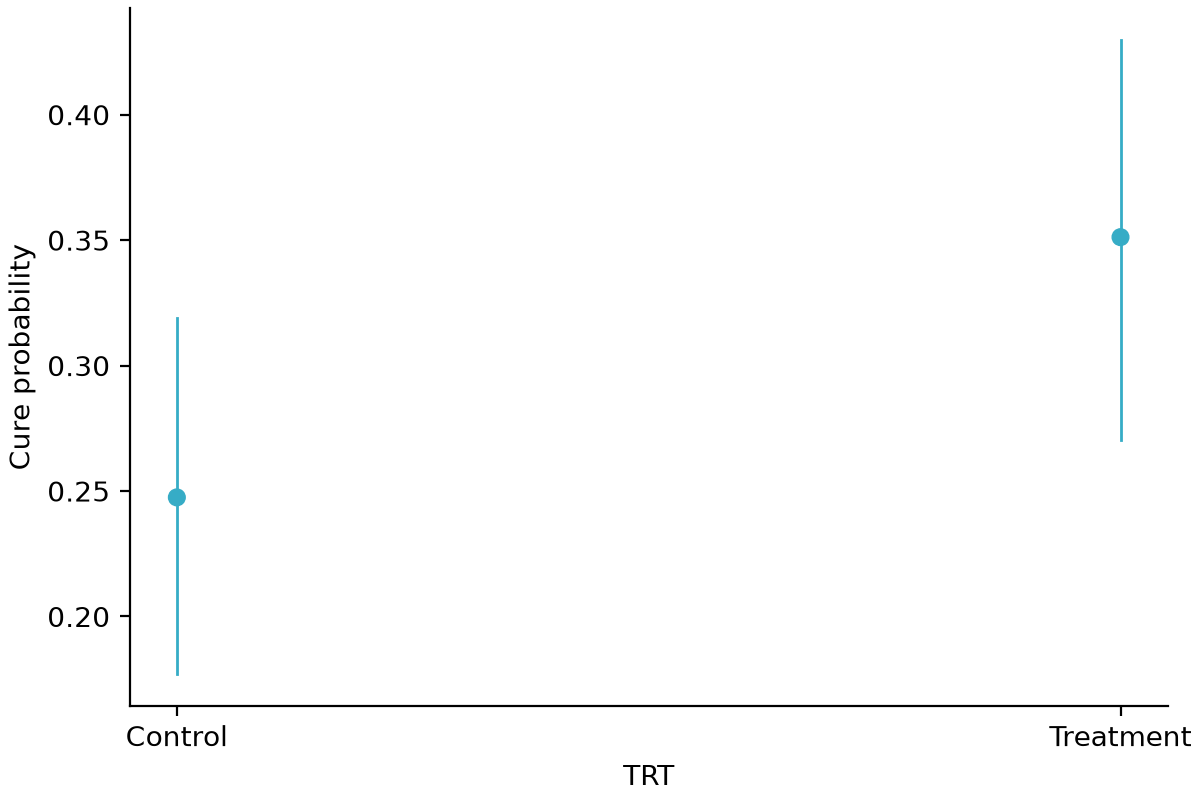

In [6]:
fig, ax = plt.subplots()
bmb.interpret.plot_predictions(
    model, idata, conditional={"TRT": [0, 1]}, target="cure", prob=0.95, on=ax
)
ax.set(
    ylabel="Cure probability",
    xticks=[0, 1],
    xticklabels=["Control", "Treatment"],
);

`comparisons` estimates the difference in cure probability between treatment and control. Multiply the estimate and interval bounds by 100 to express the difference in percentage points. The calculation subtracts control from treatment within each posterior draw and summarizes those differences to obtain the credible interval.

The cure formula includes only treatment, so this comparison does not depend on age.

In [7]:
cure_comparison = bmb.interpret.comparisons(
    model,
    idata,
    contrast={"TRT": [0, 1]},
    conditional={"age": [0.0]},
    target="cure",
    comparison="diff",
    prob=0.95,
)
cure_comparison.summary

,term,estimate_type,age,value,estimate,lower_2.5%,upper_97.5%
0,TRT,diff,0.0,0_vs_1,0.103722,-0.003387,0.206473


## Compare survival curves

We compare the mixture-cure model and a Weibull proportional hazards model with the Kaplan–Meier estimate for each treatment group. The model predictions use the centered mean age. We plot up to time 15, extending beyond the longest observed follow-up of about 9.64 to show the predicted survival curves over a longer period. The Weibull PH curves approach zero as time increases, while the mixture-cure curves approach the estimated cure probability.

For the mixture-cure model, we convert the mean event time among susceptible subjects to the Weibull scale with `beta = mu / gamma(1 + 1 / alpha)`. The `weibull_ph` family models `lam` directly, so its survival is `exp(-lam * time**alpha)`. With a shared shape and a log link for `lam`, exponentiated regression coefficients are hazard ratios.

We calculate a survival curve for each joint posterior draw returned by `bmb.interpret.predictions`, then summarize the curves with their medians and 95% credible intervals. This keeps the dependence between the parameters when computing uncertainty.

In [8]:
ordinary = bmb.Model(
    "censored(FAILTIME, status) ~ TRT + age", data, family="weibull_ph"
)
ordinary_idata = ordinary.fit(random_seed=seed)

new_data = pd.DataFrame({"TRT": [0, 1], "age": [0.0, 0.0]})
cure_pred = cure_predictions.draws.predictions
ordinary_predictions = bmb.interpret.predictions(
    ordinary, ordinary_idata, conditional={"TRT": [0, 1], "age": [0.0]}
)
ordinary_pred = ordinary_predictions.draws.predictions
time = np.linspace(0, 15, 250)

NUTS[nutpie]: [alpha, TRT, age, Intercept_centered]


Output()

In [9]:
cure_mu = cure_pred["mu"].to_numpy()[..., None]
cure_alpha = idata.posterior["alpha"].to_numpy()[..., None, None]
cure_beta = cure_mu / gamma(1 + 1 / cure_alpha)
cure_probability = cure_pred["cure"].to_numpy()[..., None]

susceptible_survival = np.exp(-((time / cure_beta) ** cure_alpha))
cure_survival = cure_probability + (1 - cure_probability) * susceptible_survival
cure_lower, cure_median, cure_upper = np.quantile(
    cure_survival, [0.025, 0.5, 0.975], axis=(0, 1)
)

In [10]:
ordinary_lam = ordinary_pred["lam"].to_numpy()[..., None]
ordinary_alpha = ordinary_idata.posterior["alpha"].to_numpy()[..., None, None]

ordinary_survival = np.exp(-ordinary_lam * time**ordinary_alpha)
ordinary_lower, ordinary_median, ordinary_upper = np.quantile(
    ordinary_survival, [0.025, 0.5, 0.975], axis=(0, 1)
)

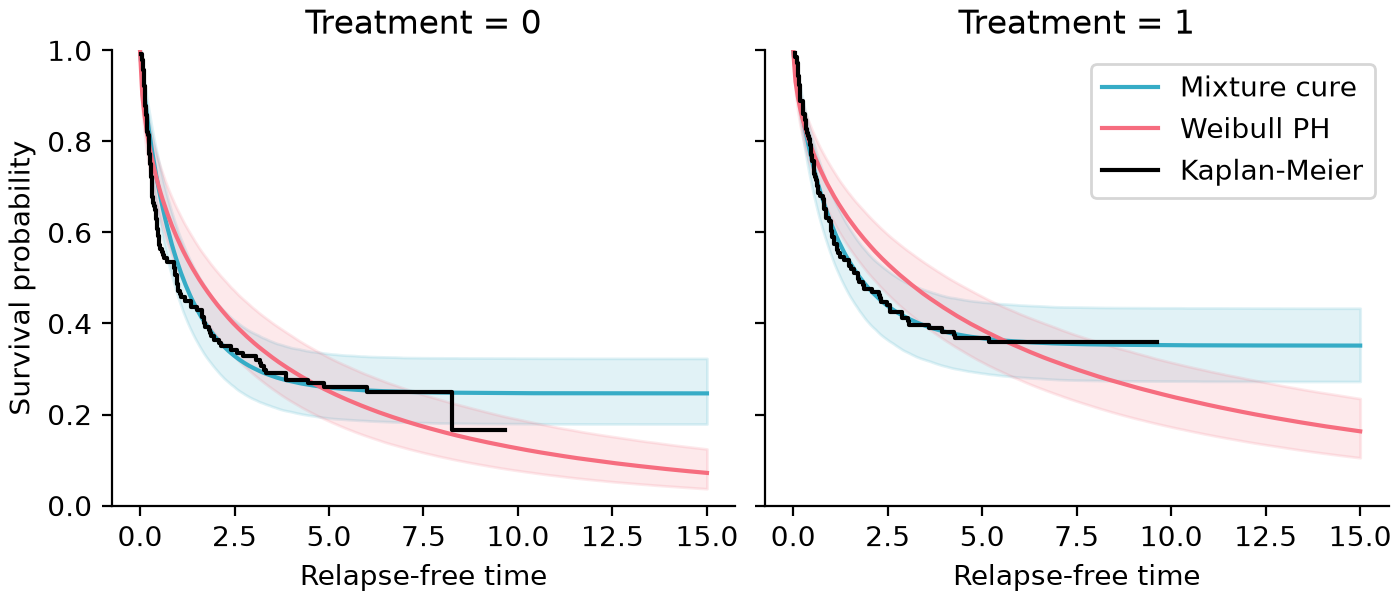

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
for group, ax in enumerate(axes):
    ax.plot(time, cure_median[group], color="C0", label="Mixture cure")
    ax.fill_between(time, cure_lower[group], cure_upper[group], color="C0", alpha=0.15)

    ax.plot(time, ordinary_median[group], color="C1", label="Weibull PH")
    ax.fill_between(
        time, ordinary_lower[group], ordinary_upper[group], color="C1", alpha=0.15
    )

    subset = data[data["TRT"] == group]
    observed = subset.loc[subset["FAILCENS"] == 1, "FAILTIME"]
    right_censored = subset.loc[subset["FAILCENS"] == 0, "FAILTIME"]
    km = ecdf(CensoredData(uncensored=observed, right=right_censored))
    ax.step(
        km.sf.quantiles,
        km.sf.probabilities,
        where="post",
        color="black",
        label="Kaplan-Meier",
    )
    ax.set(title=f"Treatment = {group}", xlabel="Relapse-free time", ylim=(0, 1))

axes[0].set(ylabel="Survival probability")
axes[1].legend();

## Predict event times

With `kind="response"`, `model.predict` draws event times for new subjects. Cured subjects have time `np.inf`, so the fraction of infinite draws estimates their cure probability.

In [12]:
response = model.predict(
    idata, data=new_data, kind="response", inplace=False, random_seed=seed
).predictions["FAILTIME"]
np.isinf(response).mean(dim=("chain", "draw"))

<xarray.DataArray 'FAILTIME' (__obs__: 2)> Size: 16B
array([0.261 , 0.3465])
Coordinates:
  * __obs__  (__obs__) int64 16B 0 1

With `kind="response_conditional"`, we also supply `FAILTIME` and `status` to condition predictions on the censoring limits. We consider subjects in the control group at the centered mean age with no observed relapse by time 2, 3, 4, or 5. This uses right censoring, as in the dataset.

A right-censored subject may relapse later or be cured and never relapse. The predicted event times are therefore at least the supplied censoring limit and can include `np.inf`. Each infinite draw represents a cured subject, while each finite draw represents a later relapse.

Both probabilities in the table are conditioned on no relapse by the censoring time. The fraction of infinite draws estimates `P(cured | no relapse by the censoring time)`. This probability increases with longer follow-up without relapse because fewer susceptible subjects remain event-free. The other column estimates the probability of relapse by time 5 under the same condition.

In [13]:
conditional_data = pd.DataFrame(
    {
        "TRT": [0] * 4,
        "age": [0.0] * 4,
        "FAILTIME": [2.0, 3.0, 4.0, 5.0],
        "status": ["right"] * 4,
    }
)
conditional_response = model.predict(
    idata,
    data=conditional_data,
    kind="response_conditional",
    inplace=False,
    random_seed=seed,
).predictions["FAILTIME"]

pd.DataFrame(
    {
        "Censoring": conditional_data["status"],
        "Censoring time": conditional_data["FAILTIME"],
        "P(event by time 5)": (conditional_response <= 5)
        .mean(dim=("chain", "draw"))
        .to_numpy(),
        "P(cured)": np.isinf(conditional_response)
        .mean(dim=("chain", "draw"))
        .to_numpy(),
    }
)

,Censoring,Censoring time,P(event by time 5),P(cured)
0,right,2.0,0.2995,0.66700
1,right,3.0,0.1395,0.81525
2,right,4.0,0.0500,0.90275
3,right,5.0,0.0000,0.95325


Long follow-up helps distinguish cure from an event that has not happened yet. The estimated cure fraction also depends on the susceptible Weibull distribution, so changing priors or shortening follow-up can affect the survival plateau.